In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [3]:
images = []
fits_files = ['M13_0001.fits', 'M13_0002.fits', 'M13_0003.fits', 'M13_0004.fits', 'M13_0005.fits']

for file in fits_files:
    with fits.open(f"{file}") as hdul:
        data=hdul[0].data
        images.append(data)

In [4]:
images

[array([[489, 474, 519, ..., 447, 541, 519],
        [517, 508, 489, ..., 517, 490, 499],
        [500, 453, 518, ..., 537, 514, 537],
        ...,
        [449, 490, 519, ..., 469, 508, 541],
        [500, 521, 514, ..., 502, 478, 549],
        [480, 516, 535, ..., 494, 527, 491]], dtype=uint16),
 array([[494, 529, 549, ..., 492, 535, 560],
        [540, 530, 479, ..., 484, 514, 496],
        [500, 517, 514, ..., 520, 518, 552],
        ...,
        [498, 515, 509, ..., 527, 533, 531],
        [499, 495, 505, ..., 521, 447, 541],
        [513, 541, 522, ..., 522, 521, 472]], dtype=uint16),
 array([[517, 475, 503, ..., 515, 531, 531],
        [521, 434, 489, ..., 575, 484, 499],
        [492, 498, 516, ..., 535, 486, 512],
        ...,
        [504, 506, 515, ..., 486, 538, 518],
        [497, 536, 509, ..., 521, 485, 539],
        [560, 515, 573, ..., 520, 506, 541]], dtype=uint16),
 array([[487, 490, 546, ..., 478, 522, 522],
        [496, 533, 505, ..., 513, 511, 486],
        [551,

In [5]:
#3.2 --- Plot Images ---

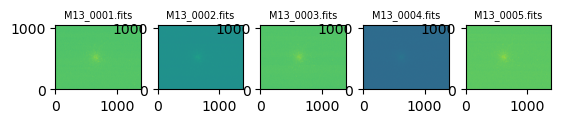

In [13]:
fig, axes = plt.subplots(1, 5)

for i, image in enumerate(images):
    im = axes[i].imshow(image, origin='lower')
    axes[i].set_title(f"M13_000{i+1}.fits", size=7)     #barely see star

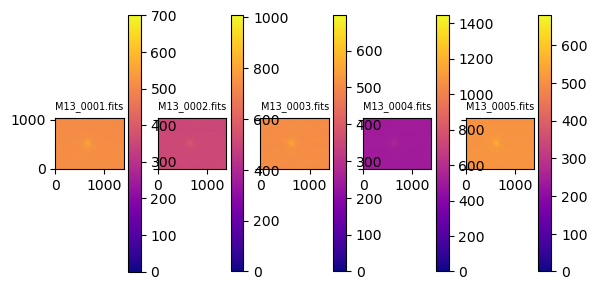

In [39]:
fig, axes = plt.subplots(1, 5, sharex=True, sharey=True)

for i, image in enumerate(images):
    vmin=0
    vmax=1000
    im = axes[i].imshow(image, cmap="plasma", origin='lower')
    axes[i].set_title(f"M13_000{i+1}.fits", size=7)
    fig.colorbar(im)
#I notice that images 1,3, and 5 look different from 2 and 4 even though the data is all around 500

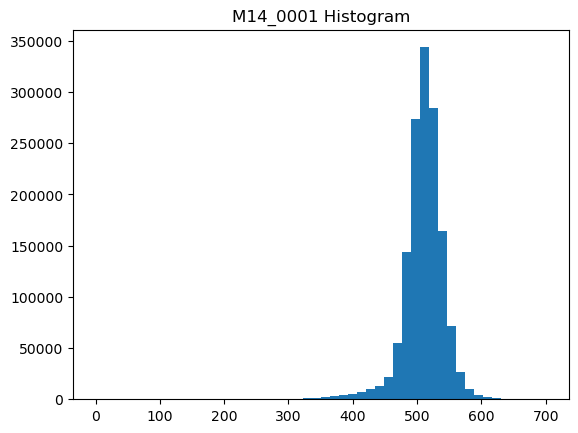

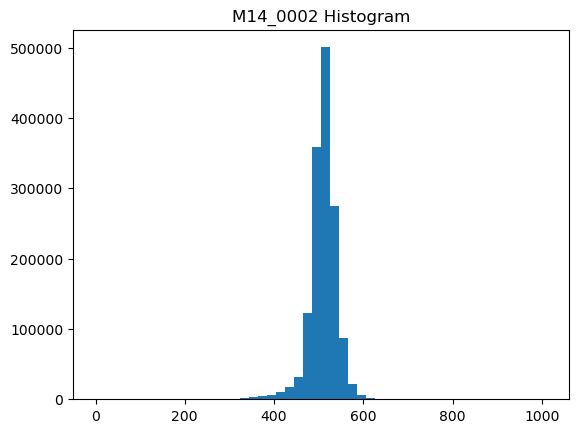

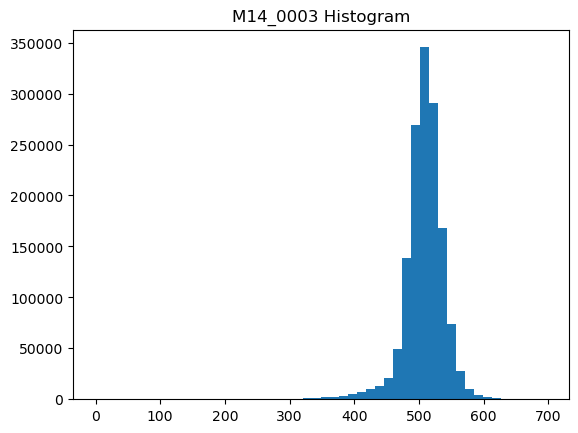

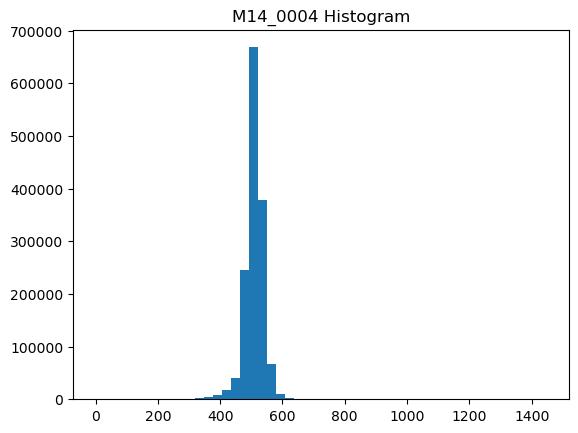

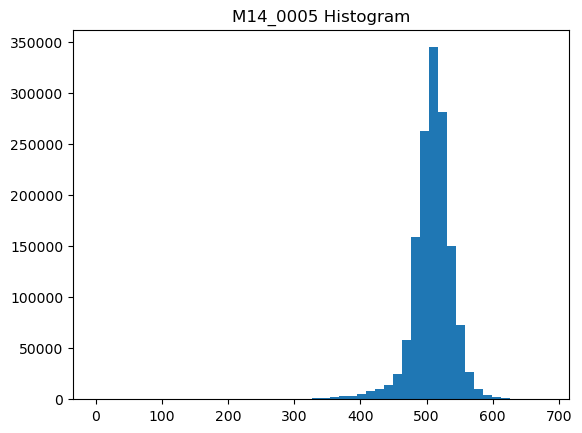

In [43]:
#3.3 --- Plot Histograms ---
for i, image, in enumerate(images):
    plt.figure
    plt.hist(image.ravel(), bins=50)
    plt.title(f"M14_000{i+1} Histogram")
    plt.show()

plt.show()

In [50]:
#x axis shows the data value, and y shows the number of pixels
#bins=50 means the histogram is divided up into 50 parts, 50 rectangles make up graph
#For all histograms, the data is centered around 500 for pixel intensity
#The data is spread out from about 100-200 pixels from 500, depending on the histogram
#median/mean pixel intensity
for i in images:
    print(np.median(i))
    print(np.mean(i))
# 1: Median = 512.0, Mean = 510.47
# 2: Median = 511.0, Mean = 509.746
# 3: Median = 510.0, Mean = 508.04987
# 4: Median = 509.0, Mean = 507.9
# 5: Median = 510.0, Mean = 508.79

512.0
510.4706668600796
511.0
509.7460150033157
510.0
508.0498729000884
509.0
507.90583554376656
510.0
508.7919920148099


In [51]:
#3.4 --- Combine and Normalize Images ---

In [52]:
combined = np.median(np.array(images), axis=0)
median_intensity = np.median(combined)

<function matplotlib.pyplot.show(close=None, block=None)>

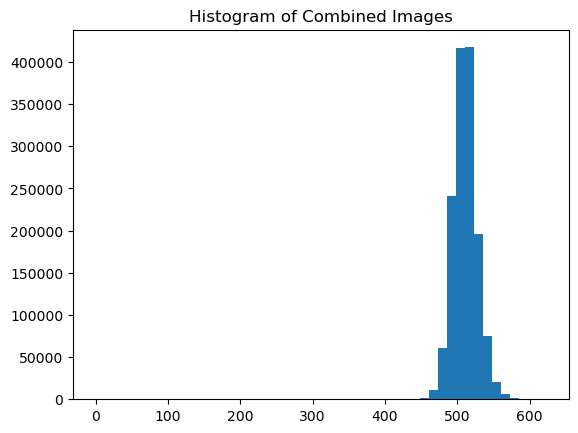

In [53]:
plt.figure()
plt.hist(combined.ravel(), bins=50)
plt.title("Histogram of Combined Images")
plt.show

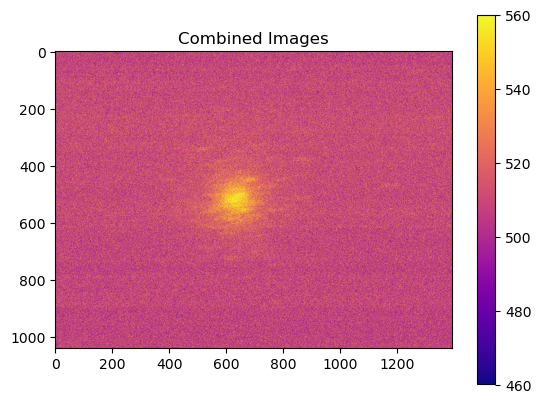

In [55]:
vmin = median_intensity - 50
vmax = median_intensity + 50
plt.figure()
plt.imshow(combined, vmin=vmin, vmax=vmax, cmap = 'plasma')
plt.title("Combined Images")
plt.colorbar()
plt.show()

In [56]:
#in this combined image, the variation in pixel intensity is much clearer

In [57]:
fits.writeto("combined.fits", combined, overwrite=True)